In [6]:

# pcb board scan details:
# pmin: 4.7 mW
# pmax: 84.5 mW 
# pin: 113 mW
import sys
sys.path.append("../")
from analysis import System as syst
import matplotlib.pyplot as plt
import math
import numpy as np
from scipy.signal import periodogram, welch, find_peaks
from scipy.optimize import curve_fit as fit
fit_freq = 1.0955e5
def signal(t, a, b, c):
    '''
    sine squared interference signal that the psd is fitted to
    '''
    return a * np.sin(np.pi * fit_freq * t + b) ** 2 + c
def find_nearest(array, value):
    '''
    finding the value in array closest to input value
    '''
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return array[idx]
def find_idx(array, value):
    '''
    finding the index of value in array closest to input value
    '''
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx
def pp(arr, d, i):
    '''
    applying time constraints and linear detrend to psd scan
    '''
    arr.set_data(ind = i)
    d.apply("time_gate", tmin = 0, tmax = 5e-4, inplace = True)
    d.apply("detrend", mode = "linear", inplace = True) # accounts for linear signal drift

In [7]:
# out of 33 scans, the scans below are the ones that have good signal 
usable_scans = [32, 31, 28, 27, 26, 25, 22, 21, 20, 19, 17, 16, 15]
usable_scans.sort() #ordering smallest to largest
num_scans = len(usable_scans)
rows  = math.ceil(num_scans/4) # for graphing subplots easier

# creating a piezo object, see System() class in analysis.py for details
piezo = syst(
    "piezo",
    ["/mnt/c/Users/Mitch/OneDrive - The University of Texas at Austin/Desktop/piezo_data/piezo_char_pcb_pmin4.7_pmax84.5_pin113/piezo_char_pcb_pmin4.7_pmax84.5_pin113/iter_" + str(x) + ".tdms" for x in range(33) if x in usable_scans],
    channel="X",
    set_data=True
)
# confirming files in piezo object
print(piezo.get_data())

In [8]:
# decent files: 32, 31, 28, 27, 26, 25, 22, 21, 20, 19, 17, 16, 15, 13

In [9]:
# this block is a peak finding method. find_peaks gets the max psd index within bounds, then parabolic_interp makes parabolic fit 
# to smooth the discrete data

def parabolic_interp(freqs, Pxx, peak_idx):
    # this is a 3 point parabolic fit, needed because real peak might not be exactly on a periodogram bin
    # turns out its not really needed, find_peaks gets within +/- 5Hz on its own

    # cannot fit at ends of data
    if peak_idx ==0 or peak_idx ==len(Pxx)-1:
        return freqs[peak_idx]

    #extracting psd values
    y0 = Pxx[peak_idx-1]
    y1 = Pxx[peak_idx]
    y2 = Pxx[peak_idx+1]
    # solve for the vertix of the parabola 
    denom = y0-2*y1+y2
    if denom ==0:
        return freqs[peak_idx] #division by 0
    vx = 1/2 * (y0-y2) 

    # offset bin formula
    offset_from_central_bin = vx/denom * (freqs[1]-freqs[0])
    df = freqs[1]-freqs[0]

    return freqs[peak_idx] + offset_from_central_bin
    
    
def find_driving_freq_peaks(Pxx,f,fs,f_guess,window_hz,nfft):
    
    fmin = max(0,f_guess-window_hz)
    fmax = min(fs/2,f_guess+window_hz)
    
    min_idx = np.searchsorted(f,1.05e5)
    max_idx = np.searchsorted(f,1.10e5)
   
    f_band = f[min_idx:max_idx]
    P_band = Pxx[min_idx:max_idx]
  
    peak_idxs,properties = find_peaks(P_band, prominence=np.max(P_band)*.03,height=np.max(P_band) * 0.02)    
    print(f_band[find_idx(P_band,np.max(P_band))])

    if len(peak_idxs) == 0:
        # this means that the global maximum is in the band 
        peak_idx = np.argmax(P_band)
    else:
        biggest = np.argmax(properties["prominences"]) 
        peak_idx = peak_idxs[biggest] #return the index with the largest prominance, so the most dominate curve

    # where is the actual peak globally
    global_max_idx = min_idx + peak_idx
    
    #f_refined = f[global_max_idx]
    
    f_refined = parabolic_interp(f,Pxx,global_max_idx)

    return f_refined,f,Pxx
f_sum = 0   
for i, d in enumerate(piezo.get_data()):
    pp(piezo,d,i)
    fs = d.r
    f, x1 = periodogram(d.collection[0].x, piezo.get_data()[i].r,nfft=int(fs)//2)
    avg = np.array(x1)
    f, x2 = periodogram(d.collection[1].x, piezo.get_data()[i].r, nfft= int(fs)//2)
    
    x = (np.array(x2)+avg)/2
    
    f_estimation, f_arr, Pxx = find_driving_freq_peaks(x,f,fs,f_guess=fit_freq, window_hz = .1e5,nfft=int(fs))
    f_sum += f_estimation
    print(f"File{usable_scans[i]}: driving frequency = {f_estimation:.3f} Hz")
f_avg = f_sum / len(piezo.get_data())
print(f"AVERAGE DRIVING FREQ = {f_avg:.3f} Hz")  
    

109696.0
File15: driving frequency = 109696.093 Hz
109456.0
File16: driving frequency = 109456.602 Hz
109600.0
File17: driving frequency = 109600.141 Hz
109486.0
File19: driving frequency = 109485.510 Hz
109636.0
File20: driving frequency = 109636.362 Hz
109678.0
File21: driving frequency = 109678.906 Hz
109646.0
File22: driving frequency = 109645.633 Hz
109580.0
File25: driving frequency = 109579.349 Hz
109628.0
File26: driving frequency = 109627.539 Hz
109614.0
File27: driving frequency = 109614.858 Hz
109596.0
File28: driving frequency = 109596.671 Hz
109652.0
File31: driving frequency = 109652.805 Hz
109578.0
File32: driving frequency = 109578.914 Hz
AVERAGE DRIVING FREQ = 109603.799 Hz


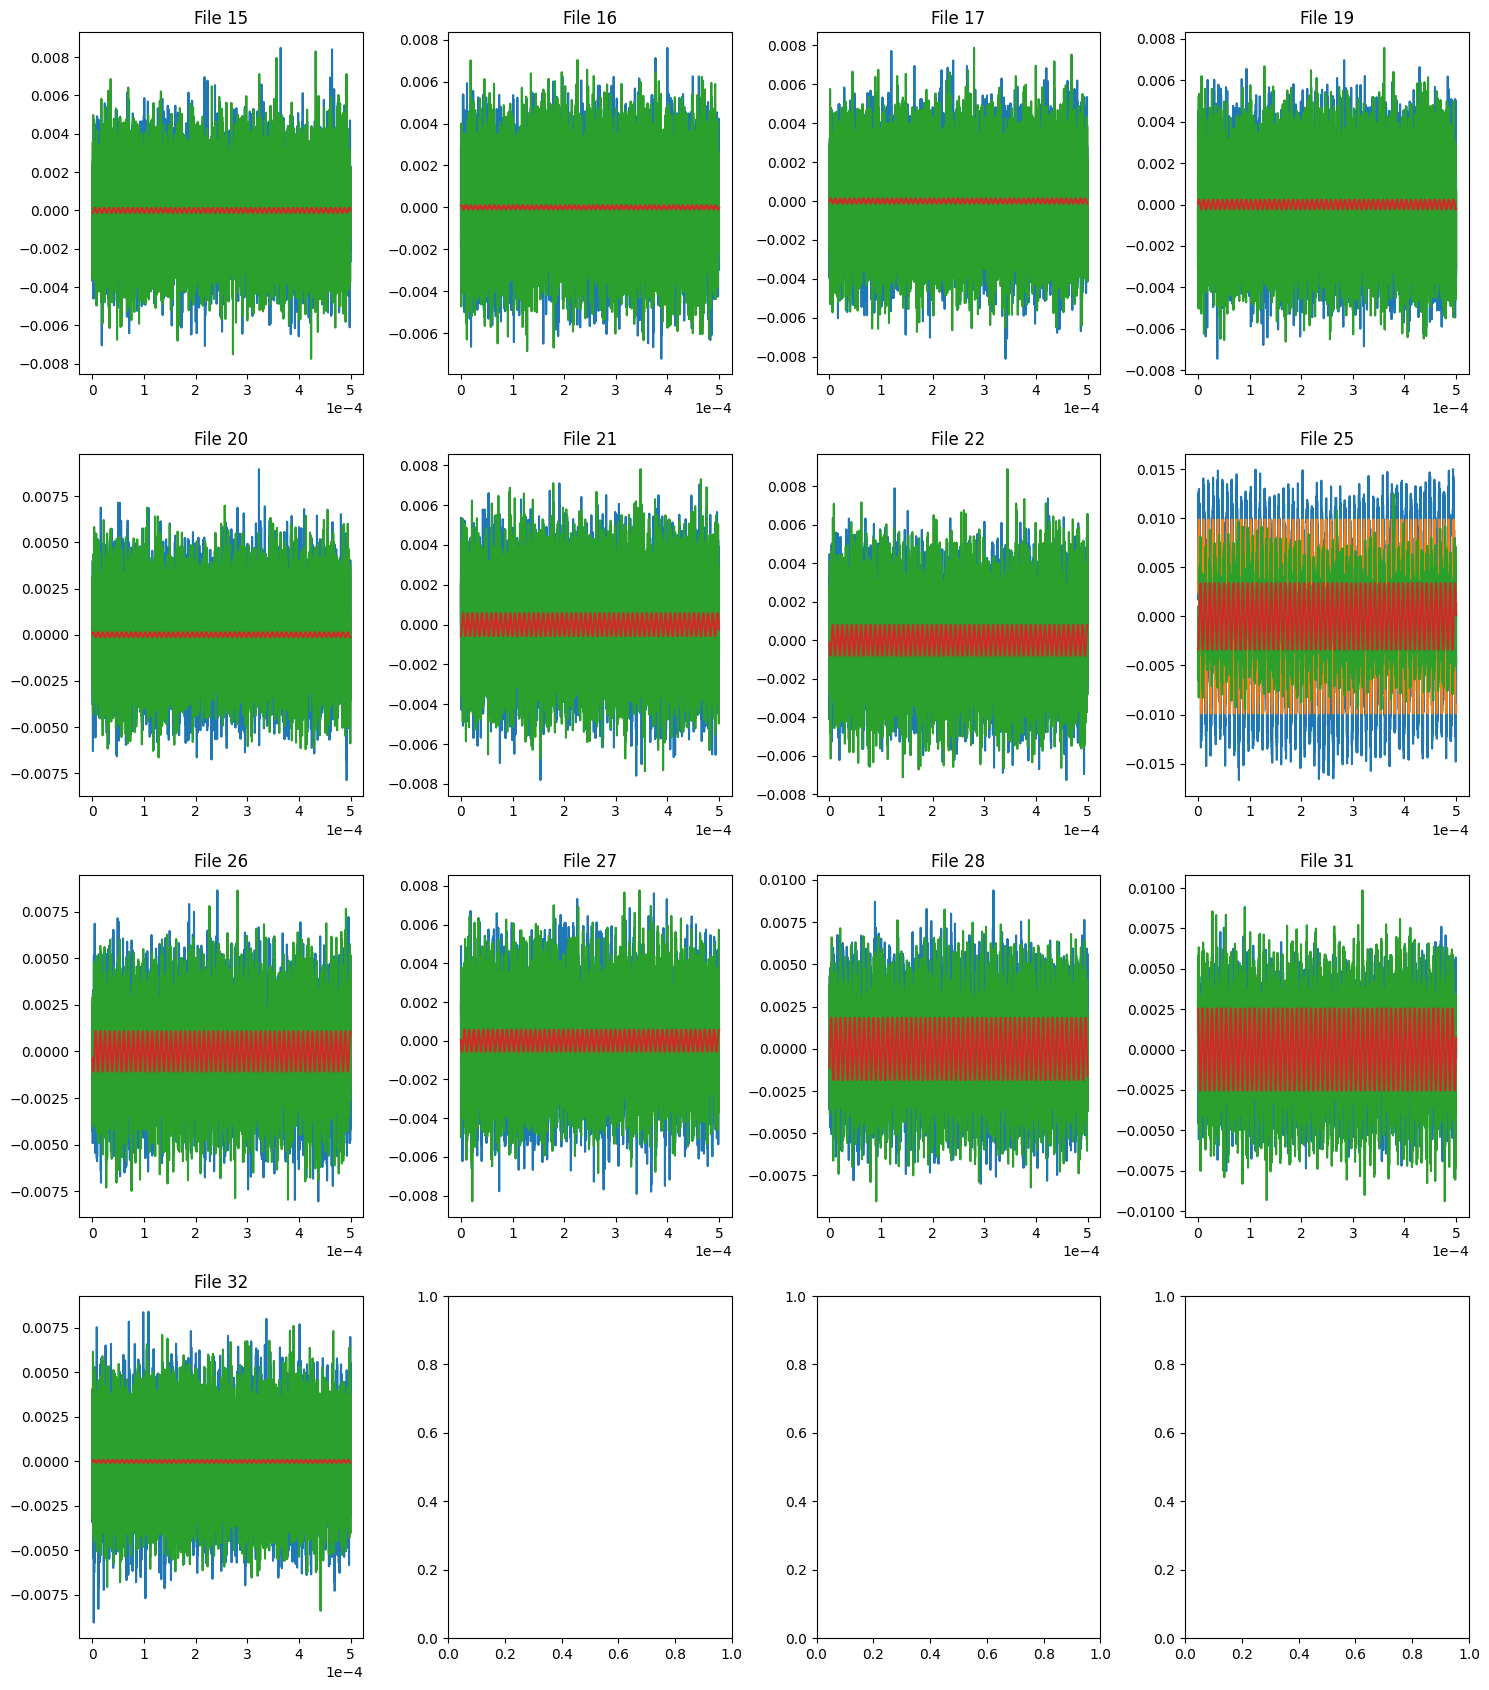

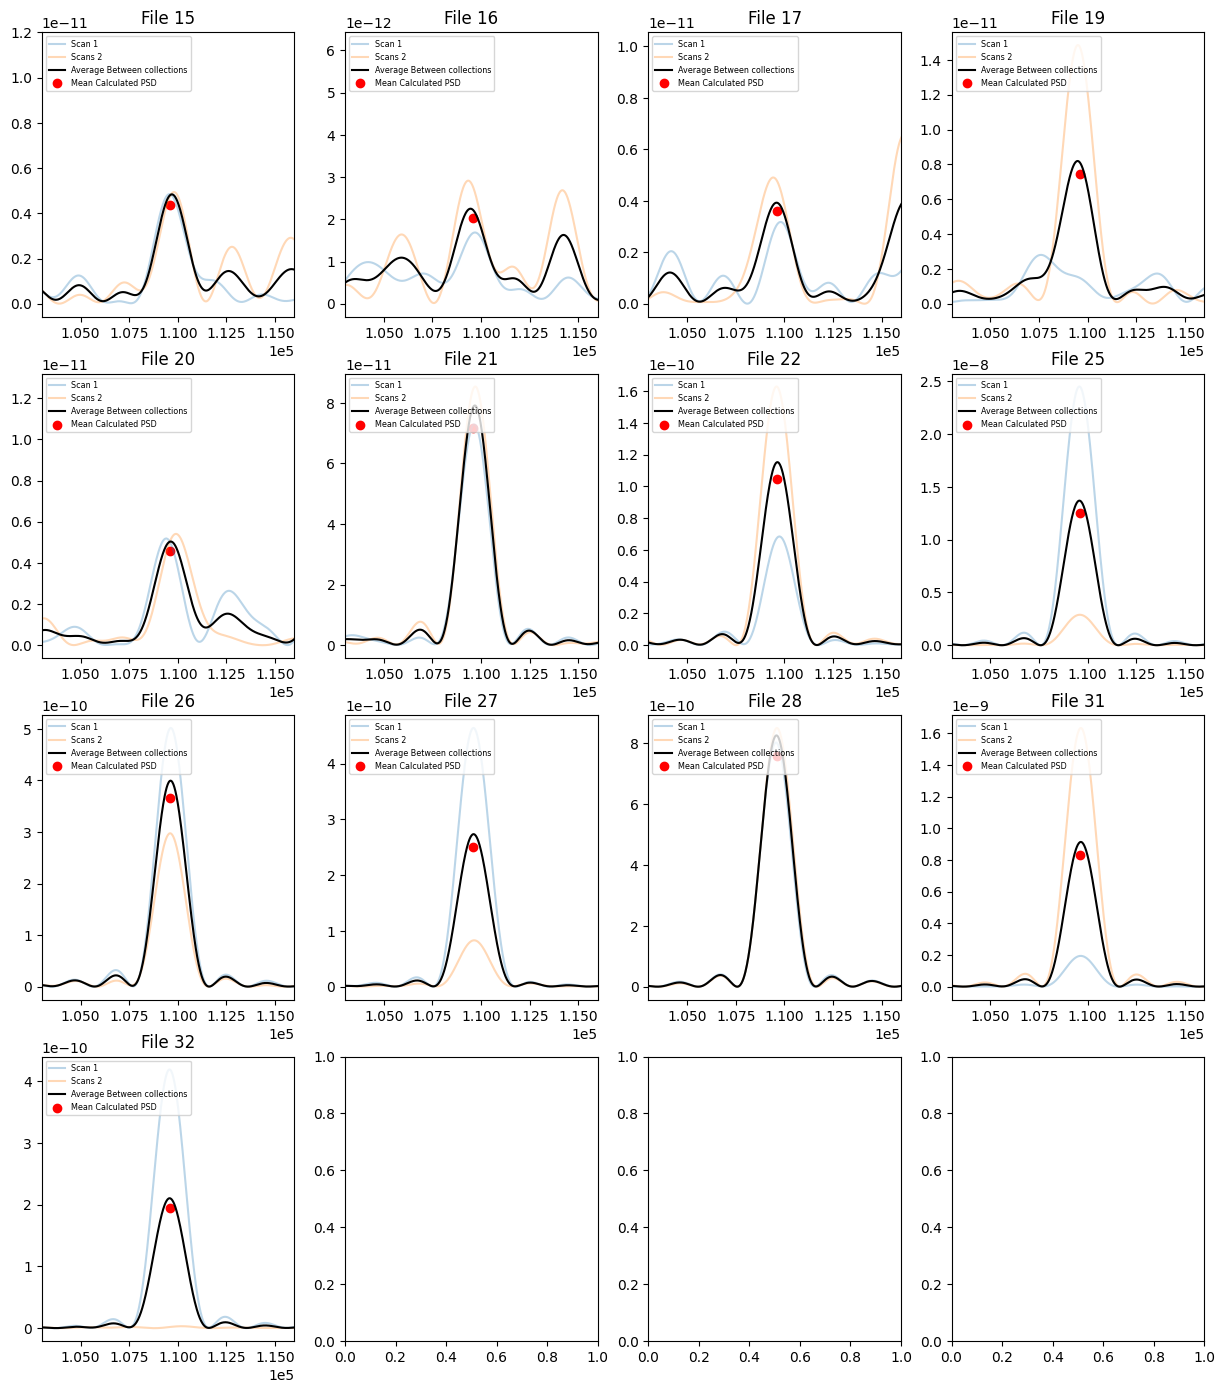

In [10]:
# creating appropriate number of subplots and empty arrays for data and fit psd (power spectral density)
fig, ax = plt.subplots(rows, 4, figsize = (15, 17))
calc_psd = []
data_psd = []
amplitudes = []

# for loop calculates a sine squared fit for every psd around f_avg Hz intensity signal (sine power reduction from 1.08e6)
for i, d in enumerate(piezo.get_data()):
    sig = 0 # placeholder for fitted signal 
    p = [] # power
    a=[] # amplitude
    # applying time gate and linear detrend to piezo object  
    pp(piezo, d, i)

    # ax[][] picks the location for the subplot

    #plots raw time-series psd for first scan in collection (each collection has two scans)
    ax[i//4][i % 4].plot(d.collection[0].t, d.collection[0].x) 
    ax[i//4][i % 4].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
    #assigns least-squares fit to raw-data signal, initial guess: [amplitude, phase, offset]
    sig = fit(signal, d.collection[0].t, d.collection[0].x, [0.005, 0, 0]) #curve_fit returns a 2D array, parameters we want are in first imbedded array
    
    # appending time series fit for amplitude and power
    a.append(sig[0][0])
    p.append(sig[0][0] ** 2 / (f_avg / (2 * np.pi))) # converting to V^2 / Hz for psd

    # plotting time vs fit, sig[0][0], sig[0][1], sig[0][2] are the fitted amp, phase, and offset parameters
    ax[i//4][i % 4].plot(d.collection[0].t, signal(d.collection[0].t, sig[0][0], sig[0][1], sig[0][2]))
    
    ax[i//4][i % 4].set_title(f"File {usable_scans[i]}")

    #plots raw time-series psd for second scan in collection
    ax[i//4][i % 4].plot(d.collection[1].t, d.collection[1].x)
    sig = fit(signal, d.collection[1].t, d.collection[1].x, [0.005, 0, 0])
    a.append(sig[0][0])
    p.append(sig[0][0] ** 2 / (f_avg/ (2 * np.pi)))
    
    # again, plotting fitted signal for second collection scan 
    ax[i//4][i % 4].plot(d.collection[1].t, signal(d.collection[1].t, sig[0][0], sig[0][1], sig[0][2]))
    
    calc_psd.append(p)
    
calc_psd = np.array(calc_psd)
plt.tight_layout()
plt.show()


fig, ax = plt.subplots(rows, 4, figsize = (15, 17))

for i, d in enumerate(piezo.get_data()):
    pp(piezo, d, i)

    p = []

    # creating a periodogram for each collection
    f, x1 = periodogram(d.collection[0].x, piezo.get_data()[i].r, nfft = int(1e6))
    p.append(x1[find_idx(f, find_nearest(f, f_avg))])
    ax[i//4][i % 4].plot(f, x1, alpha = 0.3, label="Scan 1")
    ax[i//4][i % 4].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
    avg = np.array(x1)


    f, x2 = periodogram(d.collection[1].x, piezo.get_data()[i].r, nfft = int(1e6))
    p.append(x2[find_idx(f, find_nearest(f,f_avg))])
    ax[i//4][i % 4].plot(f, x2, alpha = 0.3, label="Scans 2")
    avg = (avg + np.array(x2)) / 2
    
    ax[i//4][i % 4].plot(f, avg, c = "k", label="Average Between collections" )
    ax[i//4][i % 4].set_title(f"File {usable_scans[i]}")

    ax[i//4][i % 4].scatter(f_avg, np.mean(calc_psd[i]), c = "r", label="Mean Calculated PSD")
    ax[i//4][i % 4].set_xlim(1.03e5, 1.16e5)
    data_psd.append(p)
    ax[i//4][i % 4].legend(fontsize="xx-small", loc='upper left')

data_psd = np.array(data_psd)

plt.show()
